# Charger les données

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"C:\Users\KOURO\Desktop\Diamonds Régressionlinéaire\diamonds.csv")
df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Distribution du prix

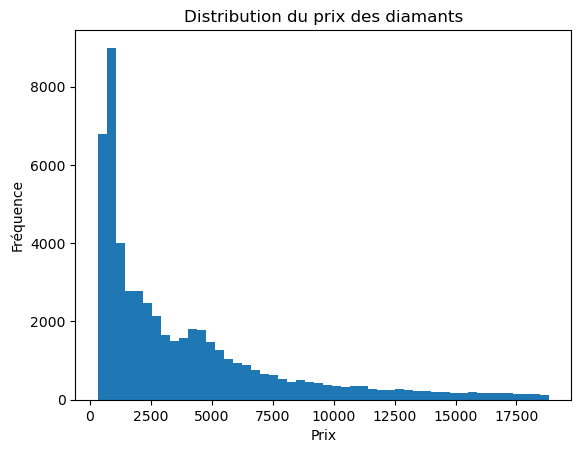

In [43]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.title("Distribution du prix des diamants")
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.show()

# Prix réel vs prix prédit

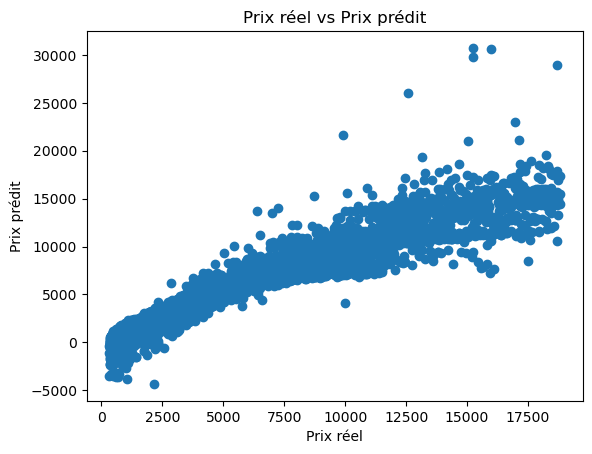

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prix réel vs Prix prédit")
plt.show()

# Résidus

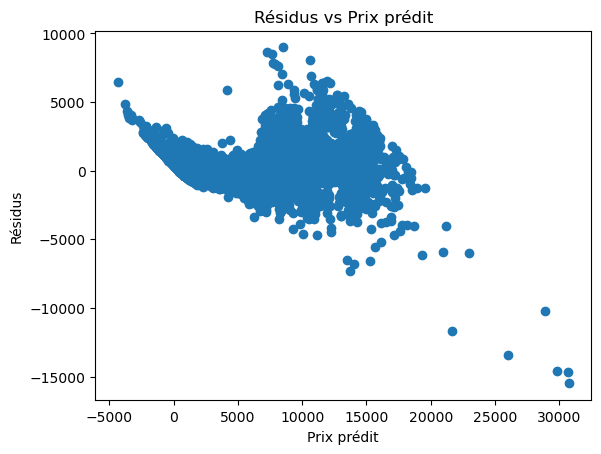

In [45]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Prix prédit")
plt.ylabel("Résidus")
plt.title("Résidus vs Prix prédit")
plt.show()

# Histogramme des erreurs

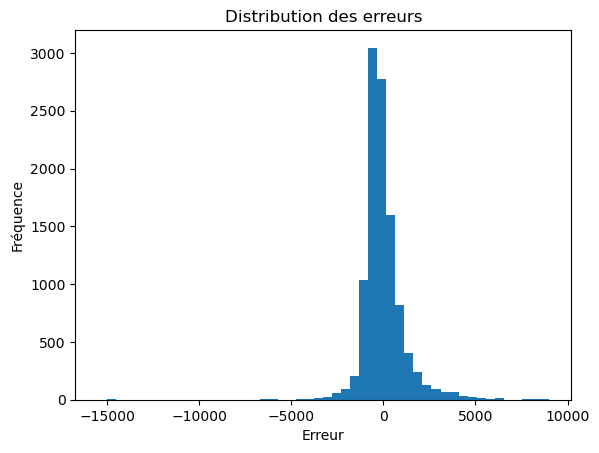

In [46]:
plt.hist(residuals, bins=50)
plt.title("Distribution des erreurs")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

# Corrélation entre variables

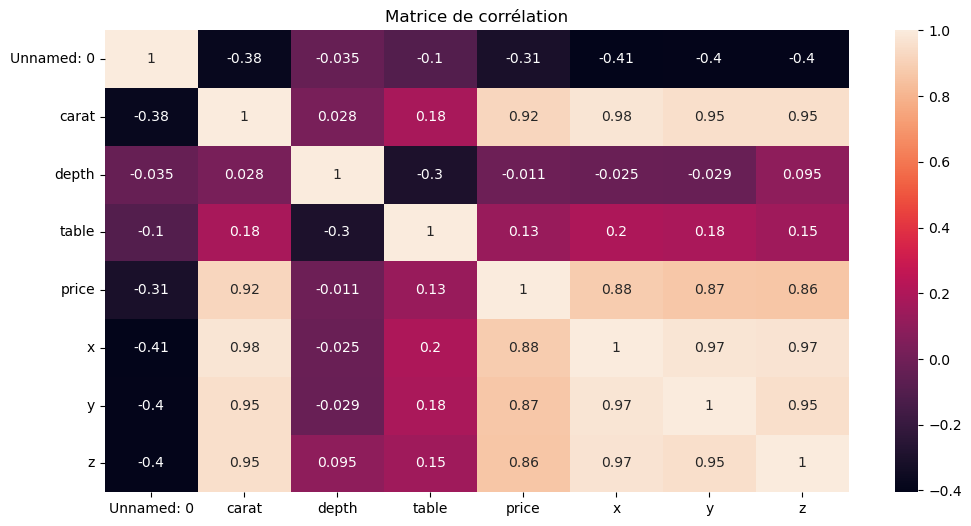

In [50]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True)
plt.title("Matrice de corrélation")
plt.show()

# Relation carat vs prix

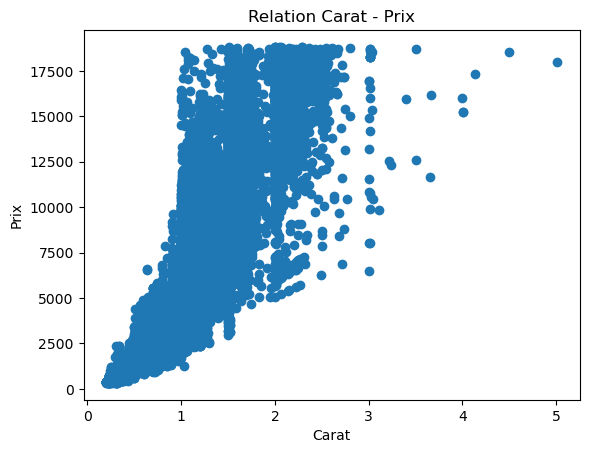

In [48]:
plt.scatter(df["carat"], df["price"])
plt.xlabel("Carat")
plt.ylabel("Prix")
plt.title("Relation Carat - Prix")
plt.show()

In [9]:
# Séparer X et y
X = df.drop("price", axis=1)
y = df["price"]

# Séparation train/test

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1 Créer un pipeline regroupant le préprocesseur construit lors de la session précédente et une instance du modèle de régression linéaire.

In [ ]:
# Créer le préprocesseur

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["carat", "depth", "table", "x", "y", "z"]
categorical_features = ["cut", "color", "clarity"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 2 Entraîner le modèle. 

In [36]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Faire des prédictions

In [51]:
y_pred = model.predict(X_test)

# 3 Evaluer sa qualité en utilisant diverses métriques.

In [52]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 1288705.477851675


# MSE (erreur quadratique moyenne)

In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 1288705.477851675


Interprétation :
Le MSE mesure l’erreur moyenne au carré
Il pénalise fortement les grosses erreurs

valeur élevée = erreurs importantes sur certaines prédictions
mais ce n’est pas directement interprétable en euros
 Conclusion :

Le modèle fait des erreurs notables
Mais le MSE seul ne suffit pas pour juger la performance

# RMSE (racine de MSE)

In [53]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE :", rmse)

RMSE : 1135.2116445190627


Le RMSE est l’erreur moyenne réelle
Ici il est exprimé en dollars
 Donc mon  modèle se trompe en moyenne de :
 ≈ 1135 $ sur le prix d’un diamant

 Analyse :

Si un diamant coûte 3000 $
 erreur ≈ 38%  (moyen)

Si un diamant coûte 8000 $
erreur ≈ 14%  (correct)

 Conclusion :
 Le modèle est acceptable mais pas très précis


# R² (score de détermination)

In [54]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 :", r2)

R2 : 0.9189331350419387


Interprétation :
R² mesure la qualité globale du modèle
Il indique la part de variance expliquée

 Ici :
 91.89% de la variation du prix est expliquée par le modèle

 Analyse :
0.0 → mauvais modèle
0.5 → moyen
0.9 → bon
1.0 → parfait

 Donc :
 le  modèle est bon

# CONCLUSION GLOBALE 

Le modèle de régression linéaire présente des performances globalement satisfaisantes avec un R² de 0.9189, indiquant qu’il explique environ 92% de la variance du prix des diamants.
Cependant, le RMSE de 1135 montre que les prédictions peuvent s’écarter significativement des valeurs réelles, ce qui révèle les limites du modèle linéaire pour capturer des relations complexes dans les données.